In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 让图表在 notebook 中显示
%matplotlib inline

# 显示设置
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 读取数据
df = pd.read_excel('df_clean.xlsx')

# 查看基本信息
print(df.shape)
display(df.head())
display(df.info())

(397884, 15)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,YearMonth,Week,DayOfWeek,IsWeekend,Hour,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,2010-12-01,48,2,0,8,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,48,2,0,8,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,2010-12-01,48,2,0,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,48,2,0,8,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,48,2,0,8,20.34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  int64         
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Date         397884 non-null  datetime64[ns]
 9   YearMonth    397884 non-null  datetime64[ns]
 10  Week         397884 non-null  int64         
 11  DayOfWeek    397884 non-null  int64         
 12  IsWeekend    397884 non-null  int64         
 13  Hour         397884 non-null  int64         
 14  Revenue      397884 non-null  float64       
dtypes: datetime64[ns](3), float64(2), 

None

In [7]:
# 复制一份，避免污染原始数据
df_clean = df.copy()

# 时间字段处理
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# 如果 YearMonth 不是标准时间格式，可以重新生成一个分析更方便的月份字段
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

# 再补充几个常用字段
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['MonthNum'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth_dt'] = df_clean['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
# 构造周起始时间（按周一）
df_clean['WeekStart'] = df_clean['InvoiceDate'].dt.to_period('W').apply(lambda r: r.start_time)

# 确认关键字段
display(df_clean[['InvoiceNo', 'CustomerID', 'InvoiceDate', 'Revenue', 'Month', 'YearMonth_dt','WeekStart']].head())

,InvoiceNo,CustomerID,InvoiceDate,Revenue,Month,YearMonth_dt,WeekStart
0,536365,17850,2010-12-01 08:26:00,15.30,2010-12,2010-12-01,2010-11-29
1,536365,17850,2010-12-01 08:26:00,20.34,2010-12,2010-12-01,2010-11-29
2,536365,17850,2010-12-01 08:26:00,22.00,2010-12,2010-12-01,2010-11-29
3,536365,17850,2010-12-01 08:26:00,20.34,2010-12,2010-12-01,2010-11-29
4,536365,17850,2010-12-01 08:26:00,20.34,2010-12,2010-12-01,2010-11-29


In [8]:
#确定订单级总表
order_level = (
    df_clean.groupby('InvoiceNo')
    .agg({
        'CustomerID': 'first',
        'InvoiceDate': 'min',
        'Revenue': 'sum'
    })
    .reset_index()
)

order_level['Month'] = order_level['InvoiceDate'].dt.to_period('M').astype(str)
order_level['YearMonth_dt'] = order_level['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
order_level['Year'] = order_level['InvoiceDate'].dt.year
order_level['MonthNum'] = order_level['InvoiceDate'].dt.month
order_level['Week'] = order_level['InvoiceDate'].dt.isocalendar().week.astype(int)
order_level['DayOfWeek'] = order_level['InvoiceDate'].dt.dayofweek
order_level['Hour'] = order_level['InvoiceDate'].dt.hour
order_level['IsWeekend'] = order_level['DayOfWeek'].isin([5, 6]).astype(int)

display(order_level.head())
print(order_level.shape)

,InvoiceNo,CustomerID,InvoiceDate,Revenue,Month,YearMonth_dt,Year,MonthNum,Week,DayOfWeek,Hour,IsWeekend
0,536365,17850,2010-12-01 08:26:00,139.12,2010-12,2010-12-01,2010,12,48,2,8,0
1,536366,17850,2010-12-01 08:28:00,22.20,2010-12,2010-12-01,2010,12,48,2,8,0
2,536367,13047,2010-12-01 08:34:00,278.73,2010-12,2010-12-01,2010,12,48,2,8,0
3,536368,13047,2010-12-01 08:34:00,70.05,2010-12,2010-12-01,2010,12,48,2,8,0
4,536369,13047,2010-12-01 08:35:00,17.85,2010-12,2010-12-01,2010,12,48,2,8,0


(18532, 12)


# Time series

In [9]:
monthly_ts = (
    order_level.groupby('YearMonth_dt')
    .agg(
        order_count=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_ts['AOV'] = monthly_ts['revenue'] / monthly_ts['order_count']

display(monthly_ts)

,YearMonth_dt,order_count,revenue,AOV
0,2010-12-01,1400,"572,713.89",409.08
1,2011-01-01,987,"569,445.04",576.95
2,2011-02-01,997,"447,137.35",448.48
3,2011-03-01,1321,"595,500.76",450.80
4,2011-04-01,1149,"469,200.36",408.36
5,2011-05-01,1555,"678,594.56",436.40
6,2011-06-01,1393,"661,213.69",474.67
7,2011-07-01,1331,"600,091.01",450.86
8,2011-08-01,1280,"645,343.90",504.17
9,2011-09-01,1755,"952,838.38",542.93


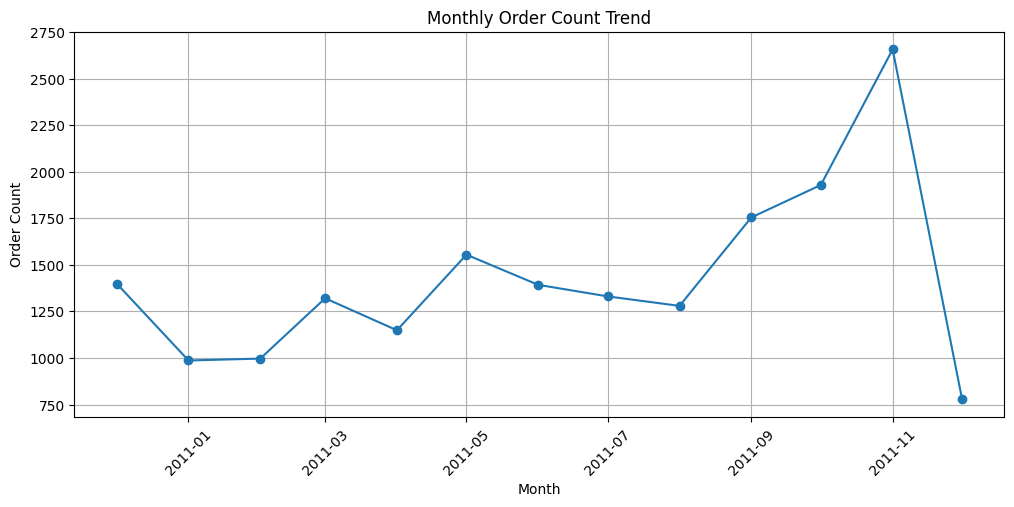

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['order_count'], marker='o')
plt.title('Monthly Order Count Trend')
plt.xlabel('Month')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

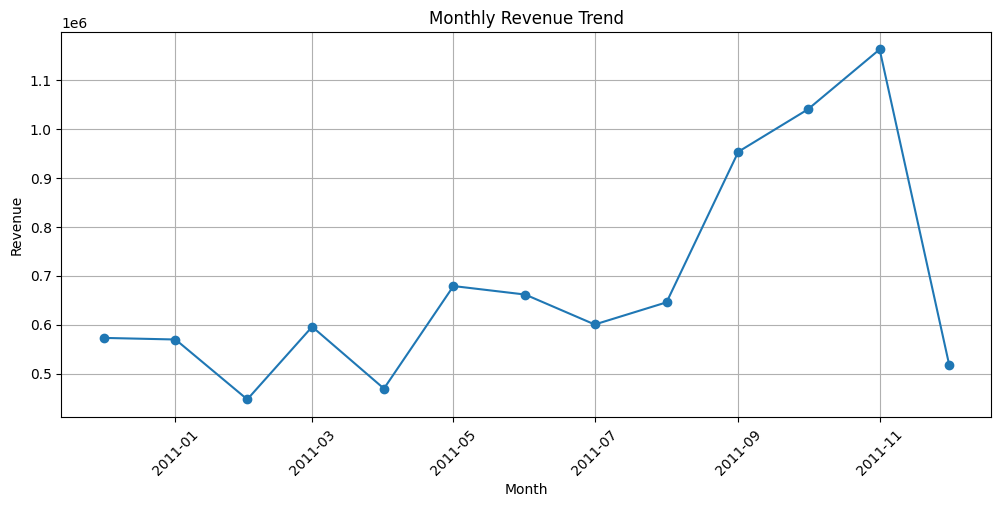

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

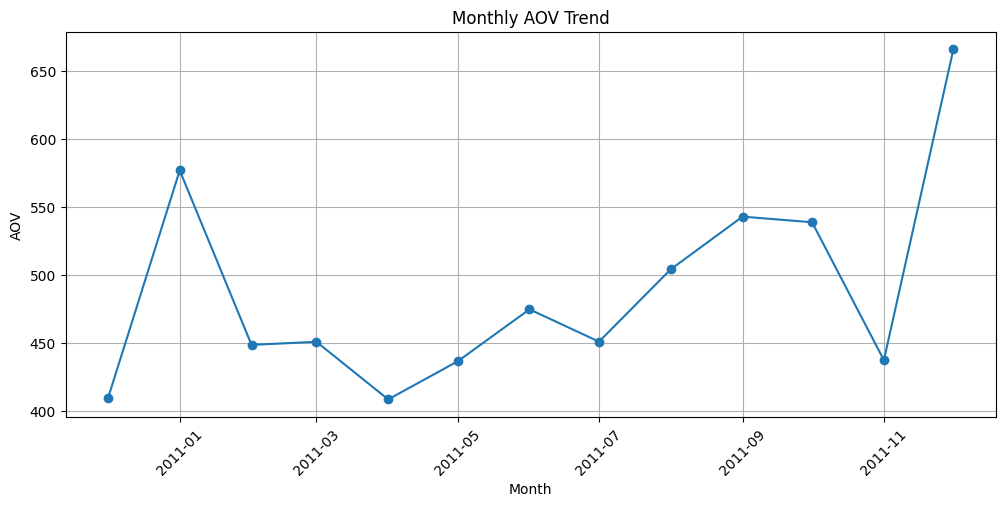

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['AOV'], marker='o')
plt.title('Monthly AOV Trend')
plt.xlabel('Month')
plt.ylabel('AOV')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [13]:
monthly_ts['order_count_mom'] = monthly_ts['order_count'].pct_change()
monthly_ts['revenue_mom'] = monthly_ts['revenue'].pct_change()
monthly_ts['AOV_mom'] = monthly_ts['AOV'].pct_change()

display(monthly_ts)

,YearMonth_dt,order_count,revenue,AOV,order_count_mom,revenue_mom,AOV_mom
0,2010-12-01,1400,"572,713.89",409.08,NaN,NaN,NaN
1,2011-01-01,987,"569,445.04",576.95,-0.30,-0.01,0.41
2,2011-02-01,997,"447,137.35",448.48,0.01,-0.21,-0.22
3,2011-03-01,1321,"595,500.76",450.80,0.32,0.33,0.01
4,2011-04-01,1149,"469,200.36",408.36,-0.13,-0.21,-0.09
5,2011-05-01,1555,"678,594.56",436.40,0.35,0.45,0.07
6,2011-06-01,1393,"661,213.69",474.67,-0.10,-0.03,0.09
7,2011-07-01,1331,"600,091.01",450.86,-0.04,-0.09,-0.05
8,2011-08-01,1280,"645,343.90",504.17,-0.04,0.08,0.12
9,2011-09-01,1755,"952,838.38",542.93,0.37,0.48,0.08


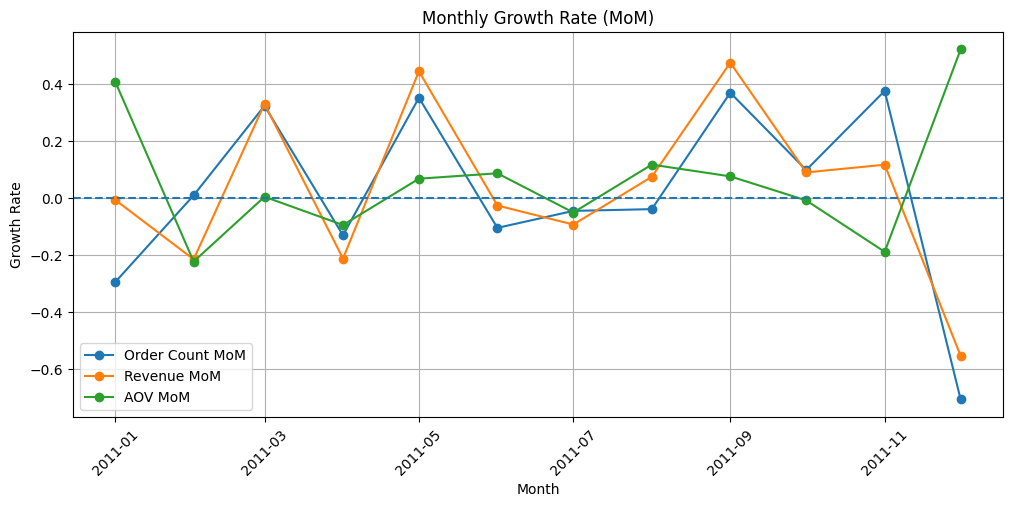

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['order_count_mom'], marker='o', label='Order Count MoM')
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['revenue_mom'], marker='o', label='Revenue MoM')
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['AOV_mom'], marker='o', label='AOV MoM')
plt.axhline(0, linestyle='--')
plt.title('Monthly Growth Rate (MoM)')
plt.xlabel('Month')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Seasonal Analysis

### Monthly 

In [15]:
monthly_seasonality = (
    order_level.groupby('MonthNum')
    .agg(
        order_count=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_seasonality['AOV'] = monthly_seasonality['revenue'] / monthly_seasonality['order_count']
display(monthly_seasonality)

,MonthNum,order_count,revenue,AOV
0,1,987,"569,445.04",576.95
1,2,997,"447,137.35",448.48
2,3,1321,"595,500.76",450.80
3,4,1149,"469,200.36",408.36
4,5,1555,"678,594.56",436.40
5,6,1393,"661,213.69",474.67
6,7,1331,"600,091.01",450.86
7,8,1280,"645,343.90",504.17
8,9,1755,"952,838.38",542.93
9,10,1929,"1,039,318.79",538.79


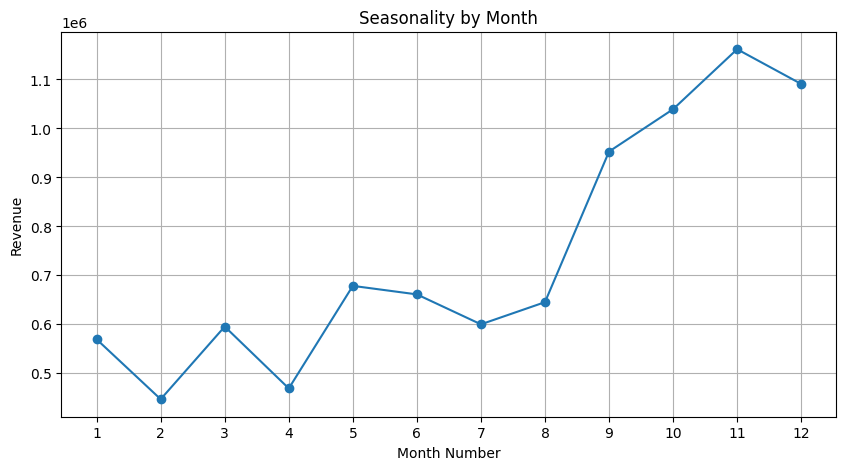

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_seasonality['MonthNum'], monthly_seasonality['revenue'], marker='o')
plt.title('Seasonality by Month')
plt.xlabel('Month Number')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### Weekly

In [17]:
weekly_seasonality = (
    order_level.groupby('Week')
    .agg(
        order_count=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

weekly_seasonality['AOV'] = weekly_seasonality['revenue'] / weekly_seasonality['order_count']
display(weekly_seasonality.head())

,Week,order_count,revenue,AOV
0,1,224,"114,865.27",512.79
1,2,233,"154,714.94",664.01
2,3,206,"175,757.98",853.19
3,4,267,"105,288.77",394.34
4,5,272,"106,095.23",390.06


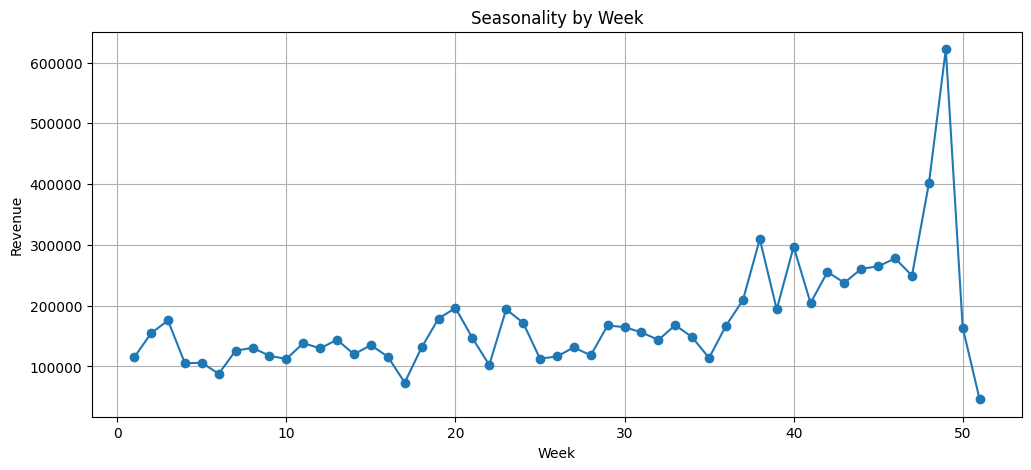

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(weekly_seasonality['Week'], weekly_seasonality['revenue'], marker='o')
plt.title('Seasonality by Week')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [19]:
# 聚合成周序列
weekly_ts = (
    df_clean.groupby('WeekStart')
    .agg(
        revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        users=('CustomerID', 'nunique')
    )
    .reset_index()
    .sort_values('WeekStart')
)

weekly_ts.head()

,WeekStart,revenue,order_count,users
0,2010-11-29,"149,386.33",402,303
1,2010-12-06,"213,447.72",489,406
2,2010-12-13,"163,770.73",401,336
3,2010-12-20,"46,109.11",108,86
4,2011-01-03,"114,865.27",224,207


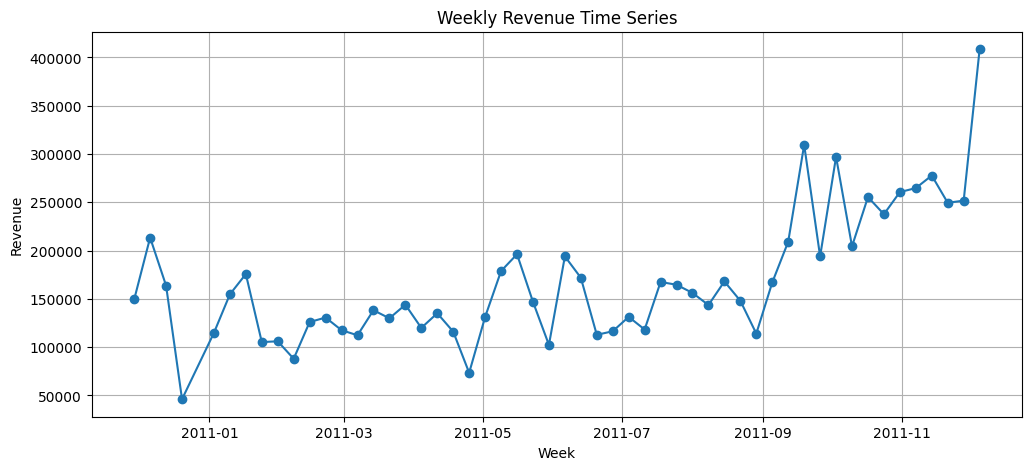

In [20]:
plt.figure(figsize=(12,5))
plt.plot(weekly_ts['WeekStart'], weekly_ts['revenue'], marker='o')
plt.title('Weekly Revenue Time Series')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [22]:
df_clean['DateOnly'] = df_clean['InvoiceDate'].dt.floor('D')
##一周少于7天的数据不要
weekly_coverage = (
    df_clean.groupby('WeekStart')
    .agg(
        revenue=('Revenue', 'sum'),
        unique_days=('DateOnly', 'nunique')
    )
    .reset_index()
)

weekly_coverage.head(), weekly_coverage.tail()

(   WeekStart    revenue  unique_days
 0 2010-11-29 149,386.33            4
 1 2010-12-06 213,447.72            6
 2 2010-12-13 163,770.73            6
 3 2010-12-20  46,109.11            4
 4 2011-01-03 114,865.27            5,
     WeekStart    revenue  unique_days
 48 2011-11-07 264,765.98            6
 49 2011-11-14 277,773.94            6
 50 2011-11-21 249,532.68            6
 51 2011-11-28 251,788.22            6
 52 2011-12-05 408,569.15            5)

In [23]:
# 设为时间索引
weekly_series = weekly_ts.set_index('WeekStart')['revenue']

# 统一频率（周一）
weekly_series = weekly_series.asfreq('W-MON')

# 填补缺失
weekly_series = weekly_series.interpolate()

In [30]:
from statsmodels.tsa.holtwinters import Holt

In [42]:
train = weekly_series.iloc[:-8]
test = weekly_series.iloc[-8:]

model = Holt(train).fit()
pred = model.forecast(len(test))


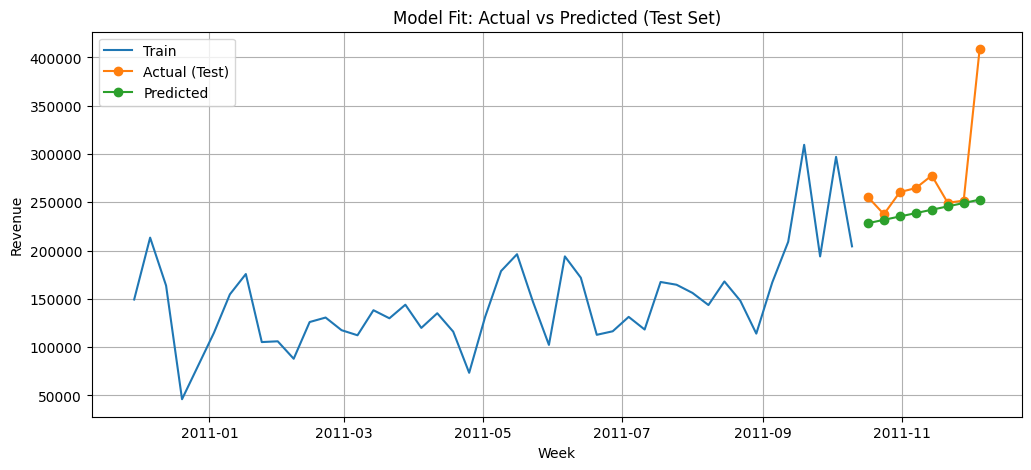

MAPE: 0.10733972590000913


In [43]:
#画图
plt.figure(figsize=(12,5))

# 训练集
plt.plot(train.index, train.values, label='Train')

# 测试集真实值
plt.plot(test.index, test.values, label='Actual (Test)', marker='o')

# 预测值
plt.plot(pred.index, pred.values, label='Predicted', marker='o')

plt.title('Model Fit: Actual vs Predicted (Test Set)')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

mape = np.mean(np.abs((test - pred) / test))
print("MAPE:", mape)

In [29]:
df_clean['YearMonth_dt'] = df_clean['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
df_clean['DateOnly'] = df_clean['InvoiceDate'].dt.floor('D')

month_coverage = (
    df_clean.groupby('YearMonth_dt')
    .agg(
        revenue=('Revenue', 'sum'),
        unique_days=('DateOnly', 'nunique'),
        min_date=('InvoiceDate', 'min'),
        max_date=('InvoiceDate', 'max')
    )
    .reset_index()
)

month_coverage

,YearMonth_dt,revenue,unique_days,min_date,max_date
0,2010-12-01,"572,713.89",20,2010-12-01 08:26:00,2010-12-23 16:06:00
1,2011-01-01,"569,445.04",24,2011-01-04 10:00:00,2011-01-31 16:59:00
2,2011-02-01,"447,137.35",24,2011-02-01 08:23:00,2011-02-28 17:01:00
3,2011-03-01,"595,500.76",27,2011-03-01 08:30:00,2011-03-31 19:55:00
4,2011-04-01,"469,200.36",21,2011-04-01 08:22:00,2011-04-28 19:53:00
5,2011-05-01,"678,594.56",25,2011-05-01 10:51:00,2011-05-31 15:41:00
6,2011-06-01,"661,213.69",26,2011-06-01 07:37:00,2011-06-30 20:08:00
7,2011-07-01,"600,091.01",26,2011-07-01 08:16:00,2011-07-31 16:04:00
8,2011-08-01,"645,343.90",26,2011-08-01 08:30:00,2011-08-31 17:16:00
9,2011-09-01,"952,838.38",26,2011-09-01 08:25:00,2011-09-30 15:52:00


In [45]:
###Hourly

In [46]:
hourly_seasonality = (
    order_level.groupby('Hour')
    .agg(
        order_count=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

hourly_seasonality['AOV'] = hourly_seasonality['revenue'] / hourly_seasonality['order_count']
display(hourly_seasonality)

,Hour,order_count,revenue,AOV
0,6,1,4.25,4.25
1,7,29,"31,059.21","1,071.01"
2,8,555,"282,115.63",508.32
3,9,1393,"842,605.17",604.89
4,10,2226,"1,261,192.57",566.57
5,11,2277,"1,104,586.10",485.11
6,12,3129,"1,378,544.13",440.57
7,13,2636,"1,173,264.75",445.09
8,14,2274,"995,629.37",437.83
9,15,2037,"966,191.75",474.32


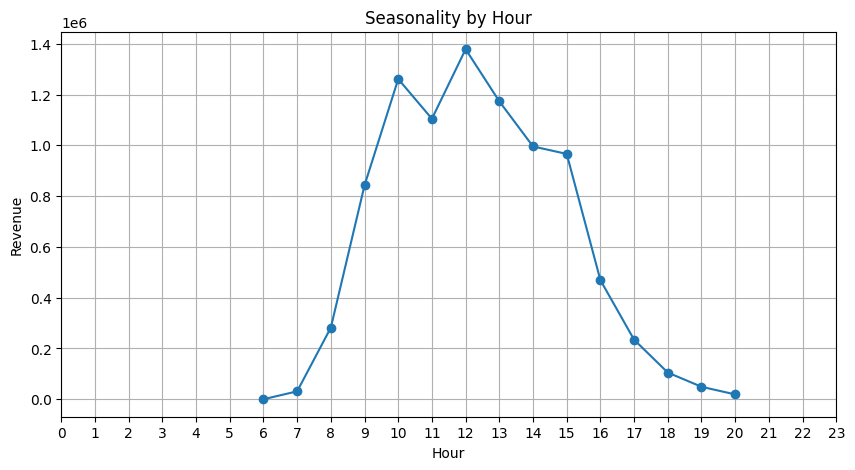

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_seasonality['Hour'], hourly_seasonality['revenue'], marker='o')
plt.title('Seasonality by Hour')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [48]:
### weekend vs weekdays

In [49]:
weekend_analysis = (
    order_level.groupby('IsWeekend')
    .agg(
        order_count=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

weekend_analysis['AOV'] = weekend_analysis['revenue'] / weekend_analysis['order_count']
weekend_analysis['Type'] = weekend_analysis['IsWeekend'].map({0: 'Weekday', 1: 'Weekend'})

display(weekend_analysis)

,IsWeekend,order_count,revenue,AOV,Type
0,0,16363,"8,118,893.68",496.17,Weekday
1,1,2169,"792,514.22",365.38,Weekend


## Outlier detection

In [50]:
monthly_ts['revenue_mean'] = monthly_ts['revenue'].mean()
monthly_ts['revenue_std'] = monthly_ts['revenue'].std()

monthly_ts['revenue_zscore'] = (
    (monthly_ts['revenue'] - monthly_ts['revenue_mean']) / monthly_ts['revenue_std']
)

# 一般 |z| > 2 认为异常
monthly_ts['revenue_anomaly'] = monthly_ts['revenue_zscore'].abs() > 2

display(monthly_ts[['YearMonth_dt', 'revenue', 'revenue_zscore', 'revenue_anomaly']])

,YearMonth_dt,revenue,revenue_zscore,revenue_anomaly
0,2010-12-01,"572,713.89",-0.50,False
1,2011-01-01,"569,445.04",-0.52,False
2,2011-02-01,"447,137.35",-1.07,False
3,2011-03-01,"595,500.76",-0.40,False
4,2011-04-01,"469,200.36",-0.97,False
5,2011-05-01,"678,594.56",-0.03,False
6,2011-06-01,"661,213.69",-0.11,False
7,2011-07-01,"600,091.01",-0.38,False
8,2011-08-01,"645,343.90",-0.18,False
9,2011-09-01,"952,838.38",1.20,False


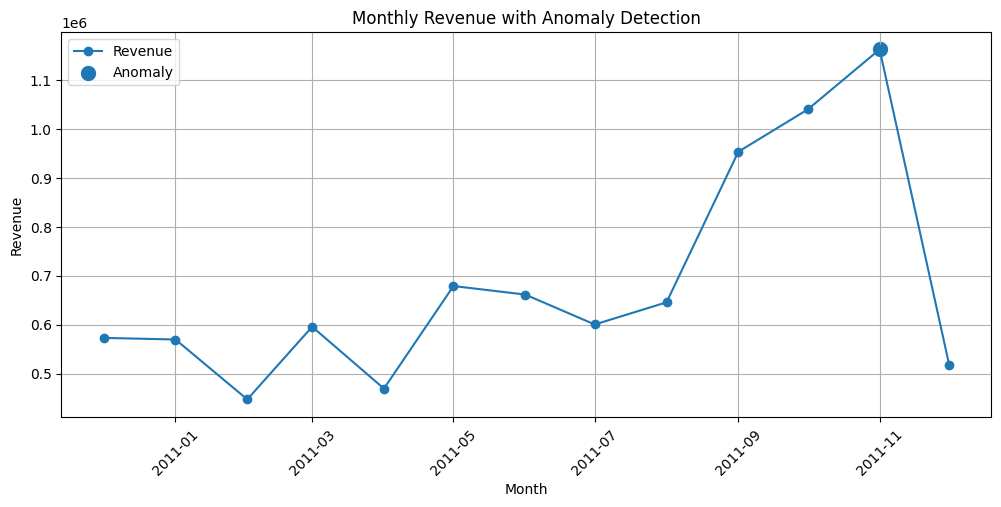

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_ts['YearMonth_dt'], monthly_ts['revenue'], marker='o', label='Revenue')

anomalies = monthly_ts[monthly_ts['revenue_anomaly']]
plt.scatter(anomalies['YearMonth_dt'], anomalies['revenue'], s=100, label='Anomaly')

plt.title('Monthly Revenue with Anomaly Detection')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Customer Growth

In [55]:
customer_growth = order_level[['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Revenue']].copy()
customer_growth = customer_growth.drop_duplicates(subset=['CustomerID', 'InvoiceNo'])
customer_growth = customer_growth.sort_values(['CustomerID', 'InvoiceDate'])

customer_growth['Month'] = customer_growth['InvoiceDate'].dt.to_period('M').astype(str)
customer_growth['YearMonth_dt'] = customer_growth['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

display(customer_growth.head(10))

,CustomerID,InvoiceNo,InvoiceDate,Revenue,Month,YearMonth_dt
1909,12346,541431,2011-01-18 10:01:00,"77,183.60",2011-01,2011-01-01
548,12347,537626,2010-12-07 14:57:00,711.79,2010-12,2010-12-01
2205,12347,542237,2011-01-26 14:30:00,475.39,2011-01,2011-01-01
4941,12347,549222,2011-04-07 10:43:00,636.25,2011-04,2011-04-01
7843,12347,556201,2011-06-09 13:01:00,382.52,2011-06,2011-06-01
10172,12347,562032,2011-08-02 08:48:00,584.91,2011-08,2011-08-01
15063,12347,573511,2011-10-31 12:25:00,"1,294.32",2011-10,2011-10-01
18363,12347,581180,2011-12-07 15:52:00,224.82,2011-12,2011-12-01
1213,12348,539318,2010-12-16 19:09:00,892.80,2010-12,2010-12-01
2115,12348,541998,2011-01-25 10:42:00,227.44,2011-01,2011-01-01


In [56]:
customer_first_purchase = (
    customer_growth.groupby('CustomerID')['InvoiceDate']
    .min()
    .reset_index()
    .rename(columns={'InvoiceDate': 'FirstPurchaseDate'})
)

customer_first_purchase['FirstPurchaseMonth'] = customer_first_purchase['FirstPurchaseDate'].dt.to_period('M').astype(str)
customer_first_purchase['YearMonth_dt'] = customer_first_purchase['FirstPurchaseDate'].dt.to_period('M').dt.to_timestamp()

display(customer_first_purchase.head())

,CustomerID,FirstPurchaseDate,FirstPurchaseMonth,YearMonth_dt
0,12346,2011-01-18 10:01:00,2011-01,2011-01-01
1,12347,2010-12-07 14:57:00,2010-12,2010-12-01
2,12348,2010-12-16 19:09:00,2010-12,2010-12-01
3,12349,2011-11-21 09:51:00,2011-11,2011-11-01
4,12350,2011-02-02 16:01:00,2011-02,2011-02-01


In [57]:
monthly_new_users = (
    customer_first_purchase.groupby('YearMonth_dt')
    .agg(new_users=('CustomerID', 'nunique'))
    .reset_index()
)

display(monthly_new_users)

,YearMonth_dt,new_users
0,2010-12-01,885
1,2011-01-01,417
2,2011-02-01,380
3,2011-03-01,452
4,2011-04-01,300
5,2011-05-01,284
6,2011-06-01,242
7,2011-07-01,188
8,2011-08-01,169
9,2011-09-01,299


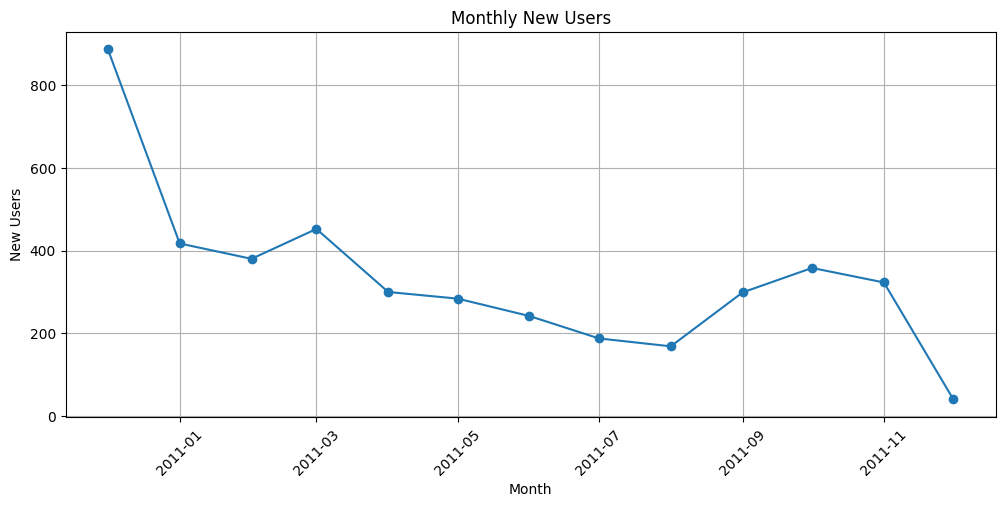

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_new_users['YearMonth_dt'], monthly_new_users['new_users'], marker='o')
plt.title('Monthly New Users')
plt.xlabel('Month')
plt.ylabel('New Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Monthly Active Users

In [59]:
monthly_active_users = (
    customer_growth.groupby('YearMonth_dt')
    .agg(active_users=('CustomerID', 'nunique'))
    .reset_index()
)

display(monthly_active_users)

,YearMonth_dt,active_users
0,2010-12-01,885
1,2011-01-01,741
2,2011-02-01,758
3,2011-03-01,974
4,2011-04-01,856
5,2011-05-01,1056
6,2011-06-01,991
7,2011-07-01,949
8,2011-08-01,935
9,2011-09-01,1266


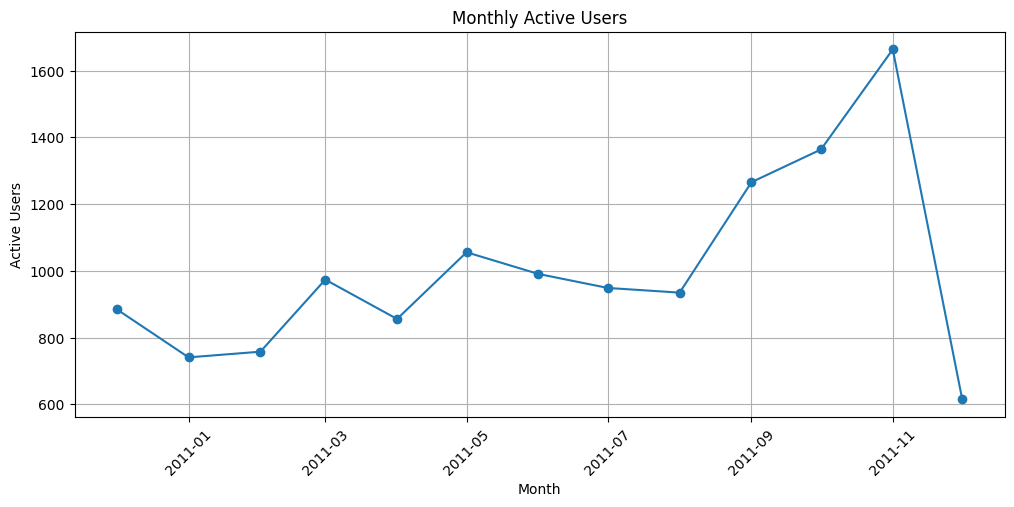

In [60]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_active_users['YearMonth_dt'], monthly_active_users['active_users'], marker='o')
plt.title('Monthly Active Users')
plt.xlabel('Month')
plt.ylabel('Active Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## User Retention

In [61]:
customer_month = customer_growth[['CustomerID', 'YearMonth_dt']].drop_duplicates().copy()
customer_month = customer_month.sort_values(['CustomerID', 'YearMonth_dt'])

display(customer_month.head())

,CustomerID,YearMonth_dt
1909,12346,2011-01-01
548,12347,2010-12-01
2205,12347,2011-01-01
4941,12347,2011-04-01
7843,12347,2011-06-01


In [62]:
customer_month['NextMonth'] = customer_month.groupby('CustomerID')['YearMonth_dt'].shift(-1)

# 当前月份 + 1个月
customer_month['ExpectedNextMonth'] = customer_month['YearMonth_dt'] + pd.offsets.MonthBegin(1)

customer_month['Retained'] = (customer_month['NextMonth'] == customer_month['ExpectedNextMonth']).astype(int)

display(customer_month.head(10))

,CustomerID,YearMonth_dt,NextMonth,ExpectedNextMonth,Retained
1909,12346,2011-01-01,NaT,2011-02-01,0
548,12347,2010-12-01,2011-01-01,2011-01-01,1
2205,12347,2011-01-01,2011-04-01,2011-02-01,0
4941,12347,2011-04-01,2011-06-01,2011-05-01,0
7843,12347,2011-06-01,2011-08-01,2011-07-01,0
10172,12347,2011-08-01,2011-10-01,2011-09-01,0
15063,12347,2011-10-01,2011-12-01,2011-11-01,0
18363,12347,2011-12-01,NaT,2012-01-01,0
1213,12348,2010-12-01,2011-01-01,2011-01-01,1
2115,12348,2011-01-01,2011-04-01,2011-02-01,0


In [63]:
monthly_retention = (
    customer_month.groupby('YearMonth_dt')
    .agg(
        active_users=('CustomerID', 'nunique'),
        retained_users=('Retained', 'sum')
    )
    .reset_index()
)

monthly_retention['retention_rate'] = monthly_retention['retained_users'] / monthly_retention['active_users']

display(monthly_retention)

,YearMonth_dt,active_users,retained_users,retention_rate
0,2010-12-01,885,324,0.37
1,2011-01-01,741,262,0.35
2,2011-02-01,758,290,0.38
3,2011-03-01,974,304,0.31
4,2011-04-01,856,368,0.43
5,2011-05-01,1056,410,0.39
6,2011-06-01,991,365,0.37
7,2011-07-01,949,388,0.41
8,2011-08-01,935,425,0.45
9,2011-09-01,1266,489,0.39


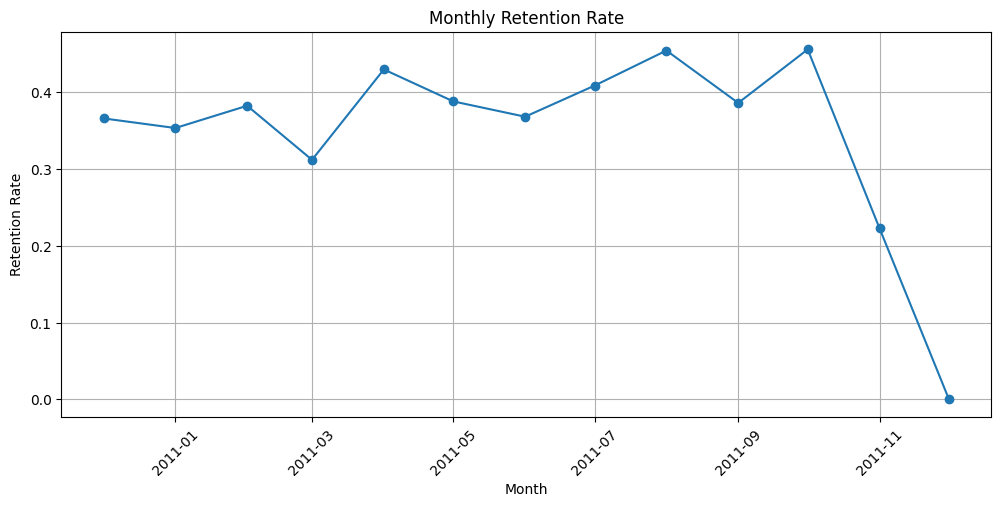

In [64]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_retention['YearMonth_dt'], monthly_retention['retention_rate'], marker='o')
plt.title('Monthly Retention Rate')
plt.xlabel('Month')
plt.ylabel('Retention Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Revenue Analysis

## New users vs Old users

In [65]:
# 把首次购买月份并回订单表
customer_first_purchase_map = customer_first_purchase[['CustomerID', 'YearMonth_dt']].rename(
    columns={'YearMonth_dt': 'FirstPurchaseMonth_dt'}
)

revenue_decomp = customer_growth.merge(
    customer_first_purchase_map,
    on='CustomerID',
    how='left'
)

revenue_decomp['customer_type'] = np.where(
    revenue_decomp['YearMonth_dt'] == revenue_decomp['FirstPurchaseMonth_dt'],
    'New',
    'Existing'
)

display(revenue_decomp.head())

,CustomerID,InvoiceNo,InvoiceDate,Revenue,Month,YearMonth_dt,FirstPurchaseMonth_dt,customer_type
0,12346,541431,2011-01-18 10:01:00,"77,183.60",2011-01,2011-01-01,2011-01-01,New
1,12347,537626,2010-12-07 14:57:00,711.79,2010-12,2010-12-01,2010-12-01,New
2,12347,542237,2011-01-26 14:30:00,475.39,2011-01,2011-01-01,2010-12-01,Existing
3,12347,549222,2011-04-07 10:43:00,636.25,2011-04,2011-04-01,2010-12-01,Existing
4,12347,556201,2011-06-09 13:01:00,382.52,2011-06,2011-06-01,2010-12-01,Existing


In [66]:
monthly_revenue_by_type = (
    revenue_decomp.groupby(['YearMonth_dt', 'customer_type'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)

monthly_revenue_pivot = monthly_revenue_by_type.pivot(
    index='YearMonth_dt',
    columns='customer_type',
    values='revenue'
).fillna(0).reset_index()

monthly_revenue_pivot['Total'] = monthly_revenue_pivot.get('New', 0) + monthly_revenue_pivot.get('Existing', 0)

display(monthly_revenue_pivot)

customer_type,YearMonth_dt,Existing,New,Total
0,2010-12-01,0.00,"572,713.89","572,713.89"
1,2011-01-01,"276,237.69","293,207.35","569,445.04"
2,2011-02-01,"288,995.28","158,142.07","447,137.35"
3,2011-03-01,"395,430.80","200,069.96","595,500.76"
4,2011-04-01,"347,188.87","122,011.49","469,200.36"
5,2011-05-01,"554,490.78","124,103.78","678,594.56"
6,2011-06-01,"525,470.74","135,742.95","661,213.69"
7,2011-07-01,"526,082.26","74,008.75","600,091.01"
8,2011-08-01,"565,587.80","79,756.10","645,343.90"
9,2011-09-01,"797,734.48","155,103.90","952,838.38"


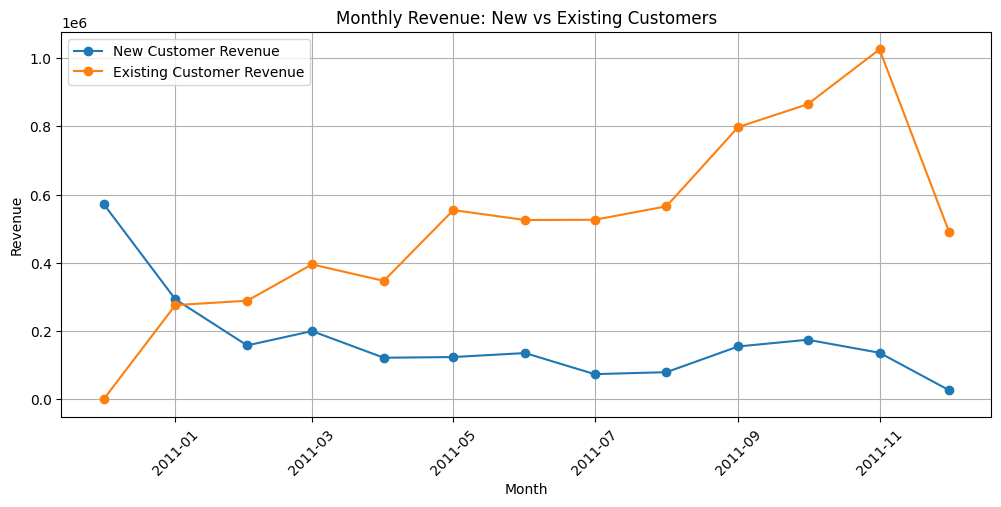

In [67]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue_pivot['YearMonth_dt'], monthly_revenue_pivot.get('New', 0), marker='o', label='New Customer Revenue')
plt.plot(monthly_revenue_pivot['YearMonth_dt'], monthly_revenue_pivot.get('Existing', 0), marker='o', label='Existing Customer Revenue')
plt.title('Monthly Revenue: New vs Existing Customers')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Loyal users vs. Returning users

In [68]:
customer_month_status = customer_growth[['CustomerID', 'YearMonth_dt']].drop_duplicates().copy()
customer_month_status = customer_month_status.sort_values(['CustomerID', 'YearMonth_dt'])

customer_month_status['PrevMonth'] = customer_month_status.groupby('CustomerID')['YearMonth_dt'].shift(1)
customer_month_status['ExpectedPrevMonth'] = customer_month_status['YearMonth_dt'] - pd.offsets.MonthBegin(1)

customer_month_status = customer_month_status.merge(
    customer_first_purchase_map,
    on='CustomerID',
    how='left'
)

def classify_customer_status(row):
    if row['YearMonth_dt'] == row['FirstPurchaseMonth_dt']:
        return 'New'
    elif row['PrevMonth'] == row['ExpectedPrevMonth']:
        return 'Retained'
    else:
        return 'Reactivated'

customer_month_status['status'] = customer_month_status.apply(classify_customer_status, axis=1)

display(customer_month_status.head(20))

,CustomerID,YearMonth_dt,PrevMonth,ExpectedPrevMonth,FirstPurchaseMonth_dt,status
0,12346,2011-01-01,NaT,2010-12-01,2011-01-01,New
1,12347,2010-12-01,NaT,2010-11-01,2010-12-01,New
2,12347,2011-01-01,2010-12-01,2010-12-01,2010-12-01,Retained
3,12347,2011-04-01,2011-01-01,2011-03-01,2010-12-01,Reactivated
4,12347,2011-06-01,2011-04-01,2011-05-01,2010-12-01,Reactivated
5,12347,2011-08-01,2011-06-01,2011-07-01,2010-12-01,Reactivated
6,12347,2011-10-01,2011-08-01,2011-09-01,2010-12-01,Reactivated
7,12347,2011-12-01,2011-10-01,2011-11-01,2010-12-01,Reactivated
8,12348,2010-12-01,NaT,2010-11-01,2010-12-01,New
9,12348,2011-01-01,2010-12-01,2010-12-01,2010-12-01,Retained


In [69]:
revenue_status = customer_growth.merge(
    customer_month_status[['CustomerID', 'YearMonth_dt', 'status']],
    on=['CustomerID', 'YearMonth_dt'],
    how='left'
)

display(revenue_status.head())

,CustomerID,InvoiceNo,InvoiceDate,Revenue,Month,YearMonth_dt,status
0,12346,541431,2011-01-18 10:01:00,"77,183.60",2011-01,2011-01-01,New
1,12347,537626,2010-12-07 14:57:00,711.79,2010-12,2010-12-01,New
2,12347,542237,2011-01-26 14:30:00,475.39,2011-01,2011-01-01,Retained
3,12347,549222,2011-04-07 10:43:00,636.25,2011-04,2011-04-01,Reactivated
4,12347,556201,2011-06-09 13:01:00,382.52,2011-06,2011-06-01,Reactivated


In [70]:
monthly_revenue_status = (
    revenue_status.groupby(['YearMonth_dt', 'status'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)

monthly_revenue_status_pivot = monthly_revenue_status.pivot(
    index='YearMonth_dt',
    columns='status',
    values='revenue'
).fillna(0).reset_index()

display(monthly_revenue_status_pivot)

status,YearMonth_dt,New,Reactivated,Retained
0,2010-12-01,"572,713.89",0.00,0.00
1,2011-01-01,"293,207.35",0.00,"276,237.69"
2,2011-02-01,"158,142.07","73,331.76","215,663.52"
3,2011-03-01,"200,069.96","119,632.99","275,797.81"
4,2011-04-01,"122,011.49","131,706.85","215,482.02"
5,2011-05-01,"124,103.78","191,209.79","363,280.99"
6,2011-06-01,"135,742.95","146,780.98","378,689.76"
7,2011-07-01,"74,008.75","203,981.30","322,100.96"
8,2011-08-01,"79,756.10","211,928.83","353,658.97"
9,2011-09-01,"155,103.90","271,264.55","526,469.93"


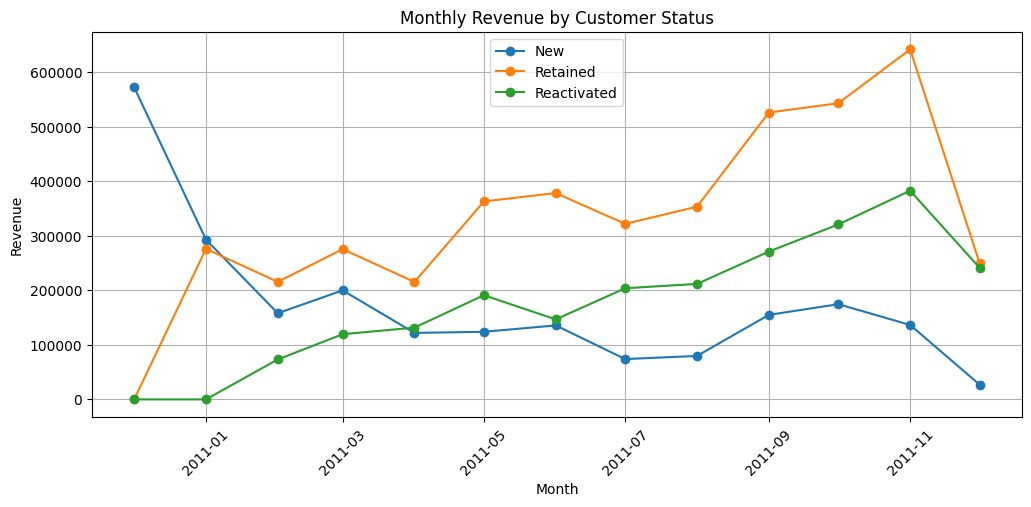

In [71]:
plt.figure(figsize=(12, 5))
for col in ['New', 'Retained', 'Reactivated']:
    if col in monthly_revenue_status_pivot.columns:
        plt.plot(monthly_revenue_status_pivot['YearMonth_dt'], monthly_revenue_status_pivot[col], marker='o', label=col)

plt.title('Monthly Revenue by Customer Status')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Revenue-driven disassembly

In [72]:
monthly_driver = (
    customer_growth.groupby('YearMonth_dt')
    .agg(
        users=('CustomerID', 'nunique'),
        orders=('InvoiceNo', 'nunique'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_driver['orders_per_user'] = monthly_driver['orders'] / monthly_driver['users']
monthly_driver['AOV'] = monthly_driver['revenue'] / monthly_driver['orders']

# 校验 revenue 是否约等于 users * orders_per_user * AOV
monthly_driver['revenue_check'] = (
    monthly_driver['users'] *
    monthly_driver['orders_per_user'] *
    monthly_driver['AOV']
)

display(monthly_driver)

,YearMonth_dt,users,orders,revenue,orders_per_user,AOV,revenue_check
0,2010-12-01,885,1400,"572,713.89",1.58,409.08,"572,713.89"
1,2011-01-01,741,987,"569,445.04",1.33,576.95,"569,445.04"
2,2011-02-01,758,997,"447,137.35",1.32,448.48,"447,137.35"
3,2011-03-01,974,1321,"595,500.76",1.36,450.80,"595,500.76"
4,2011-04-01,856,1149,"469,200.36",1.34,408.36,"469,200.36"
5,2011-05-01,1056,1555,"678,594.56",1.47,436.40,"678,594.56"
6,2011-06-01,991,1393,"661,213.69",1.41,474.67,"661,213.69"
7,2011-07-01,949,1331,"600,091.01",1.40,450.86,"600,091.01"
8,2011-08-01,935,1280,"645,343.90",1.37,504.17,"645,343.90"
9,2011-09-01,1266,1755,"952,838.38",1.39,542.93,"952,838.38"


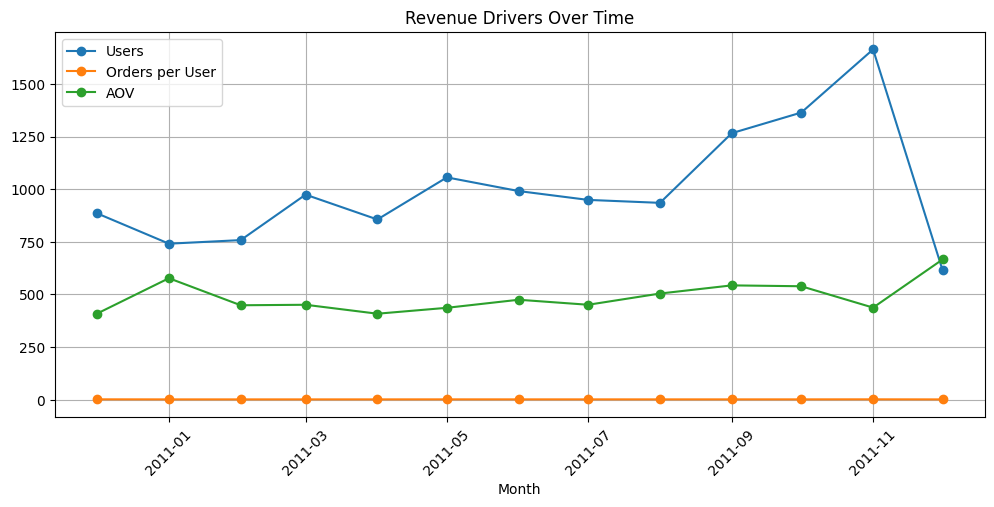

In [74]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_driver['YearMonth_dt'], monthly_driver['users'], marker='o', label='Users')
plt.plot(monthly_driver['YearMonth_dt'], monthly_driver['orders_per_user'], marker='o', label='Orders per User')
plt.plot(monthly_driver['YearMonth_dt'], monthly_driver['AOV'], marker='o', label='AOV')
plt.title('Revenue Drivers Over Time')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()